In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("supply_chain_dataset1.csv")

# Head of data
print("[1] Head of Data")
display(df.head())

# Data info and missing values
print("\n[2] Data Info & Missing Values")
df.info()

# Statistical summary
print("\n[3] Statistical Summary")
display(df.describe())

# Dataset shape
print(f"\n[4] Data Shape: {df.shape}")

# Unique SKUs
sku_col = "SKU_ID" if "SKU_ID" in df.columns else "SKU"

if sku_col in df.columns:
    print(f"Number of Unique SKUs: {df[sku_col].nunique()}")

[1] Head of Data


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70



[2] Data Info & Missing Values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     91250 non-null  object 
 1   SKU_ID                   91250 non-null  object 
 2   Warehouse_ID             91250 non-null  object 
 3   Supplier_ID              91250 non-null  object 
 4   Region                   91250 non-null  object 
 5   Units_Sold               91250 non-null  int64  
 6   Inventory_Level          91250 non-null  int64  
 7   Supplier_Lead_Time_Days  91250 non-null  int64  
 8   Reorder_Point            91250 non-null  int64  
 9   Order_Quantity           91250 non-null  int64  
 10  Unit_Cost                91250 non-null  float64
 11  Unit_Price               91250 non-null  float64
 12  Promotion_Flag           91250 non-null  int64  
 13  Stockout_Flag            91250 non-null  int

,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.0,91250.000000
mean,20.054564,471.522312,7.984000,300.068000,19.272493,12.203320,18.261800,0.101589,0.0,20.082033
std,9.068602,133.488002,3.907929,54.879945,82.340831,4.574982,7.121136,0.302109,0.0,9.503955
min,0.000000,168.000000,2.000000,201.000000,0.000000,5.020000,6.950000,0.000000,0.0,0.000000
25%,13.000000,370.000000,4.000000,252.000000,0.000000,8.180000,12.000000,0.000000,0.0,12.950000
50%,20.000000,461.000000,8.000000,300.000000,0.000000,11.990000,18.180000,0.000000,0.0,19.950000
75%,27.000000,564.000000,11.000000,346.000000,0.000000,16.320000,23.390000,0.000000,0.0,26.930000
max,59.000000,990.000000,14.000000,398.000000,499.000000,19.760000,35.100000,1.000000,0.0,61.420000



[4] Data Shape: (91250, 15)
Number of Unique SKUs: 50


In [8]:
# Remove missing values
df.dropna(inplace=True)

# Convert date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Convert numeric columns
df["Units_Sold"] = df["Units_Sold"].astype(int)
df["Inventory_Level"] = df["Inventory_Level"].astype(int)

# Calculate daily COGS
df["Daily_COGS"] = df["Units_Sold"] * df["Unit_Cost"]

# Verification
print("Data cleaning complete.")

display(df.head())

print(df.dtypes)

Data cleaning complete.


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast,Daily_COGS
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52,139.50
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63,237.15
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62,488.25
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43,334.80
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70,292.95


Date                       datetime64[ns]
SKU_ID                             object
Warehouse_ID                       object
Supplier_ID                        object
Region                             object
Units_Sold                          int64
Inventory_Level                     int64
Supplier_Lead_Time_Days             int64
Reorder_Point                       int64
Order_Quantity                      int64
Unit_Cost                         float64
Unit_Price                        float64
Promotion_Flag                      int64
Stockout_Flag                       int64
Demand_Forecast                   float64
Daily_COGS                        float64
dtype: object


In [9]:
# Aggregate SKU-level metrics
sku_stats = df.groupby("SKU_ID").agg(
    Avg_Daily_Sales=("Units_Sold", "mean"),
    Max_Daily_Sales=("Units_Sold", "max"),
    Std_Dev_Sales=("Units_Sold", "std"),
    Current_Inventory=("Inventory_Level", "last"),
    Lead_Time=("Supplier_Lead_Time_Days", "mean"),
    Unit_Cost=("Unit_Cost", "mean"),
    Total_COGS_Spend=("Daily_COGS", "sum")
).reset_index()

# Fill missing standard deviation values
sku_stats["Std_Dev_Sales"] = sku_stats["Std_Dev_Sales"].fillna(0)

# Preview results
display(sku_stats.head())

,SKU_ID,Avg_Daily_Sales,Max_Daily_Sales,Std_Dev_Sales,Current_Inventory,Lead_Time,Unit_Cost,Total_COGS_Spend
0,SKU_1,20.288219,52,8.945387,570,8.2,11.562,428617.62
1,SKU_10,20.043288,53,9.065478,352,10.2,13.774,503829.52
2,SKU_11,19.922192,49,8.956674,673,5.2,15.288,555711.23
3,SKU_12,20.161096,54,9.169058,371,7.0,11.762,432818.22
4,SKU_13,20.227397,54,9.224200,576,10.2,14.398,533348.54


In [10]:
# Calculate safety stock
sku_stats["Safety_Stock"] = (
    (sku_stats["Max_Daily_Sales"] - sku_stats["Avg_Daily_Sales"])
    * sku_stats["Lead_Time"]
)

# Calculate reorder point
sku_stats["Reorder_Point"] = (
    (sku_stats["Avg_Daily_Sales"] * sku_stats["Lead_Time"])
    + sku_stats["Safety_Stock"]
)

# Calculate days of cover
sku_stats["Days_of_Cover"] = (
    sku_stats["Current_Inventory"]
    / sku_stats["Avg_Daily_Sales"]
)

# Preview metrics
display(
    sku_stats[
        [
            "SKU_ID",
            "Avg_Daily_Sales",
            "Lead_Time",
            "Safety_Stock",
            "Reorder_Point",
            "Days_of_Cover"
        ]
    ].head()
)

,SKU_ID,Avg_Daily_Sales,Lead_Time,Safety_Stock,Reorder_Point,Days_of_Cover
0,SKU_1,20.288219,8.2,260.036603,426.4,28.095122
1,SKU_10,20.043288,10.2,336.158466,540.6,17.561989
2,SKU_11,19.922192,5.2,151.204603,254.8,33.781424
3,SKU_12,20.161096,7.0,236.872329,378.0,18.401777
4,SKU_13,20.227397,10.2,344.480548,550.8,28.476229


In [11]:
# Sort SKUs by total spend
sku_stats = sku_stats.sort_values(
    by="Total_COGS_Spend",
    ascending=False
)

# Calculate cumulative spend percentage
sku_stats["Cumulative_Spend_Pct"] = (
    sku_stats["Total_COGS_Spend"].cumsum()
    / sku_stats["Total_COGS_Spend"].sum()
)

# ABC classification logic
def abc_classify(pct):
    if pct <= 0.70:
        return "A"
    elif pct <= 0.90:
        return "B"
    else:
        return "C"

# Apply ABC ranking
sku_stats["ABC_Rank"] = sku_stats[
    "Cumulative_Spend_Pct"
].apply(abc_classify)

# Preview results
display(
    sku_stats[
        [
            "SKU_ID",
            "Total_COGS_Spend",
            "Cumulative_Spend_Pct",
            "ABC_Rank"
        ]
    ].head(10)
)

,SKU_ID,Total_COGS_Spend,Cumulative_Spend_Pct,ABC_Rank
31,SKU_38,689010.54,0.030845,A
34,SKU_40,569391.76,0.056334,A
2,SKU_11,555711.23,0.081211,A
42,SKU_48,555626.40,0.106085,A
24,SKU_31,544470.53,0.130459,A
4,SKU_13,533348.54,0.154335,A
14,SKU_22,533312.20,0.178210,A
40,SKU_46,528585.12,0.201873,A
21,SKU_29,520550.30,0.225176,A
25,SKU_32,518434.46,0.248384,A


In [12]:
# Determine inventory status
def determine_status(row):
    if row["Current_Inventory"] <= row["Reorder_Point"]:
        return "Order Now"
    elif row["Current_Inventory"] <= row["Reorder_Point"] * 1.2:
        return "Monitor"
    else:
        return "OK"

# Apply inventory status
sku_stats["Order_Status"] = sku_stats.apply(
    determine_status,
    axis=1
)

# Calculate suggested order quantity
sku_stats["Suggested_Order_Qty"] = sku_stats.apply(
    lambda x: max(
        0,
        (x["Avg_Daily_Sales"] * x["Lead_Time"] * 2)
        - x["Current_Inventory"]
    )
    if x["Order_Status"] == "Order Now"
    else 0,
    axis=1
).round(0).astype(int)

# Final report
final_report = sku_stats[
    [
        "SKU_ID",
        "ABC_Rank",
        "Current_Inventory",
        "Reorder_Point",
        "Days_of_Cover",
        "Order_Status",
        "Suggested_Order_Qty"
    ]
]

# Preview report
display(
    final_report.sort_values(
        by="Order_Status"
    ).head(15)
)

,SKU_ID,ABC_Rank,Current_Inventory,Reorder_Point,Days_of_Cover,Order_Status,Suggested_Order_Qty
28,SKU_35,A,382,333.2,19.130924,Monitor,0
49,SKU_9,B,516,487.6,25.551486,Monitor,0
4,SKU_13,A,576,550.8,28.476229,Monitor,0
46,SKU_6,A,509,488.8,25.651700,Monitor,0
35,SKU_41,C,564,504.0,28.175298,Monitor,0
27,SKU_34,C,359,330.4,17.931823,Monitor,0
38,SKU_44,C,567,402.8,28.208571,OK,0
0,SKU_1,A,570,426.4,28.095122,OK,0
20,SKU_28,B,469,384.8,23.462213,OK,0
23,SKU_30,B,394,280.0,19.669284,OK,0


/tmp/ipykernel_2641/2313426543.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


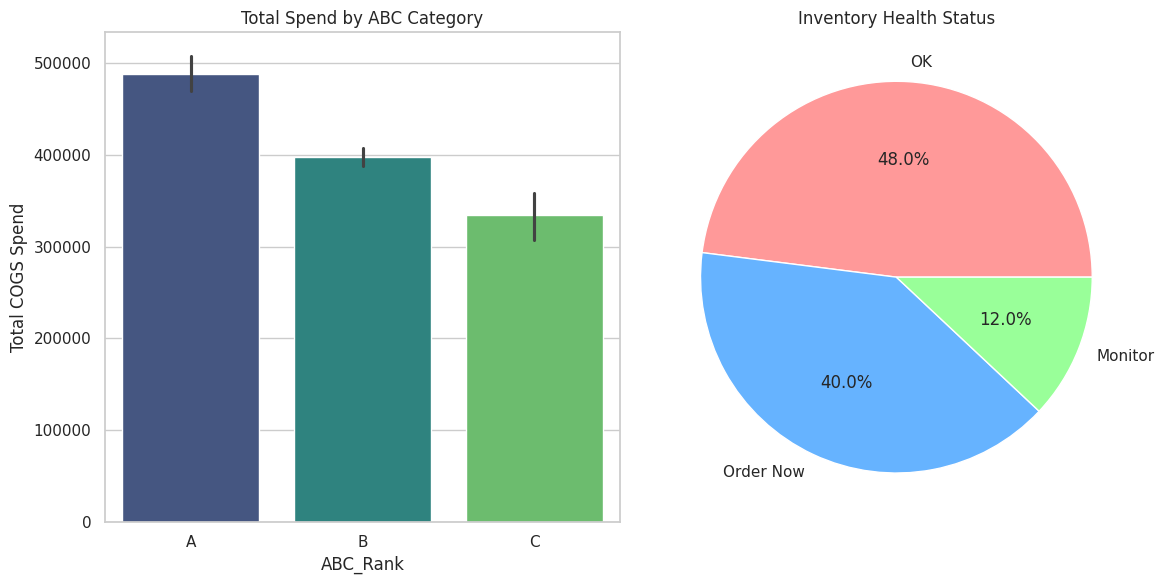

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(12, 6))

# ABC spend distribution
plt.subplot(1, 2, 1)

sns.barplot(
    x="ABC_Rank",
    y="Total_COGS_Spend",
    data=sku_stats,
    order=["A", "B", "C"],
    palette="viridis"
)

plt.title("Total Spend by ABC Category")
plt.ylabel("Total COGS Spend")

# Inventory health status
plt.subplot(1, 2, 2)

status_counts = final_report["Order_Status"].value_counts()

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=["#ff9999", "#66b3ff", "#99ff99"]
)

plt.title("Inventory Health Status")

plt.tight_layout()

plt.savefig("inventory_dashboard.png")

plt.show()

In [14]:

excel_export = final_report.copy()


excel_export["Reorder_Point"] = (
    excel_export["Reorder_Point"]
    .round(0)
    .astype(int)
)

excel_export["Days_of_Cover"] = (
    excel_export["Days_of_Cover"]
    .round(1)
)

excel_export["Avg_Daily_Sales"] = (
    sku_stats["Avg_Daily_Sales"]
    .round(2)
)

# Export report
excel_export.to_excel(
    "Purchase_Order_Report.xlsx",
    index=False
)


print("File 'Purchase_Order_Report.xlsx' has been created.")

print("\nInventory Status Summary:")
print(
    excel_export["Order_Status"].value_counts()
)

File 'Purchase_Order_Report.xlsx' has been created.

Inventory Status Summary:
Order_Status
OK           24
Order Now    20
Monitor       6
Name: count, dtype: int64


In [16]:
import joblib

# Save main processed objects
joblib.dump(df, "df_cleaned.pkl")
joblib.dump(sku_stats, "sku_stats.pkl")
joblib.dump(final_report, "final_report.pkl")

print("Project objects saved successfully.")

Project objects saved successfully.
